# Transformers for Video Game Image Super Resolution


**Video Game Super-Resolution** (VGSR)  
Eric Phann, Samantha Michael, Kidus Kidane  
DSBA 6127: AI & Deep Learning


## Introduction

This notebook will explore transformers as a newer, state-of-the-art architecture for video game image super-resolution. The intuition for this is that attention mechanisms will be useful for better detail preservation and prediction as opposed to more traditional methods like convolutional neural networks (CNNs) or generative adversarial networks (GANs).

We will refer to ["Swin IR: Image Restoration Using Swin Transformer"](https://arxiv.org/abs/2108.10257) as baseline research and model for this approach in our project.  

We will also look at ["Swin2SR: SwinV2 Transformer for Compressed
Image Super-Resolution and Restoration"](https://arxiv.org/pdf/2209.11345) as an updated version of the Swin model specifically for image super-resolution and restoration.

## SwinIR

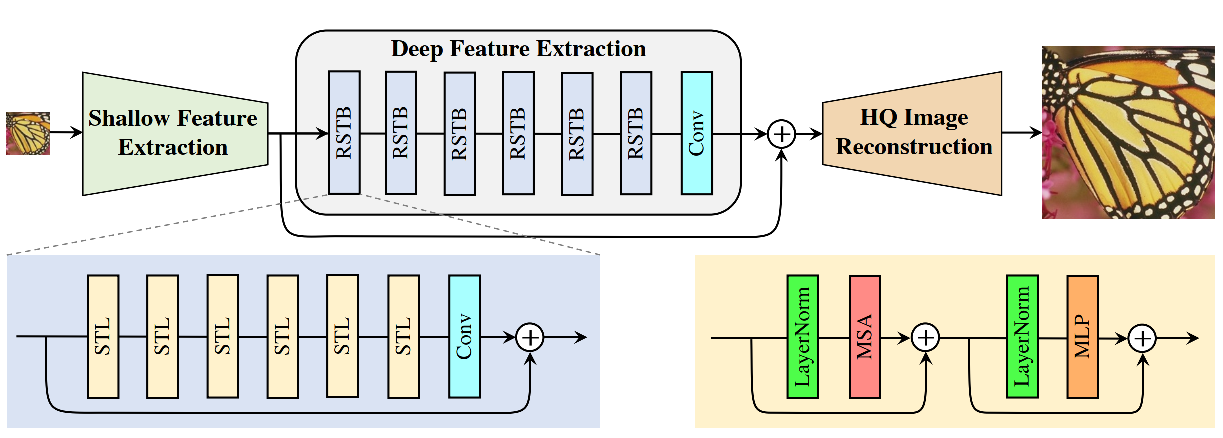

As you can see in the diagram shown, SwinIR is composed of three parts:
- Shallow feature extraction
- Deep feature extraction
- HQ image reconstruction

The deep feature extraction module contains several residual Swin Transformer blocks (RSTB) which consist of several Swin Transformer layers together with a residual connection.  

For reference, a **Swin** Transformer is a hierarchical vision transformer using "**S**hifted **Win**dows". For more info, read the paper [here](https://arxiv.org/abs/2103.14030).


## Swin2SR

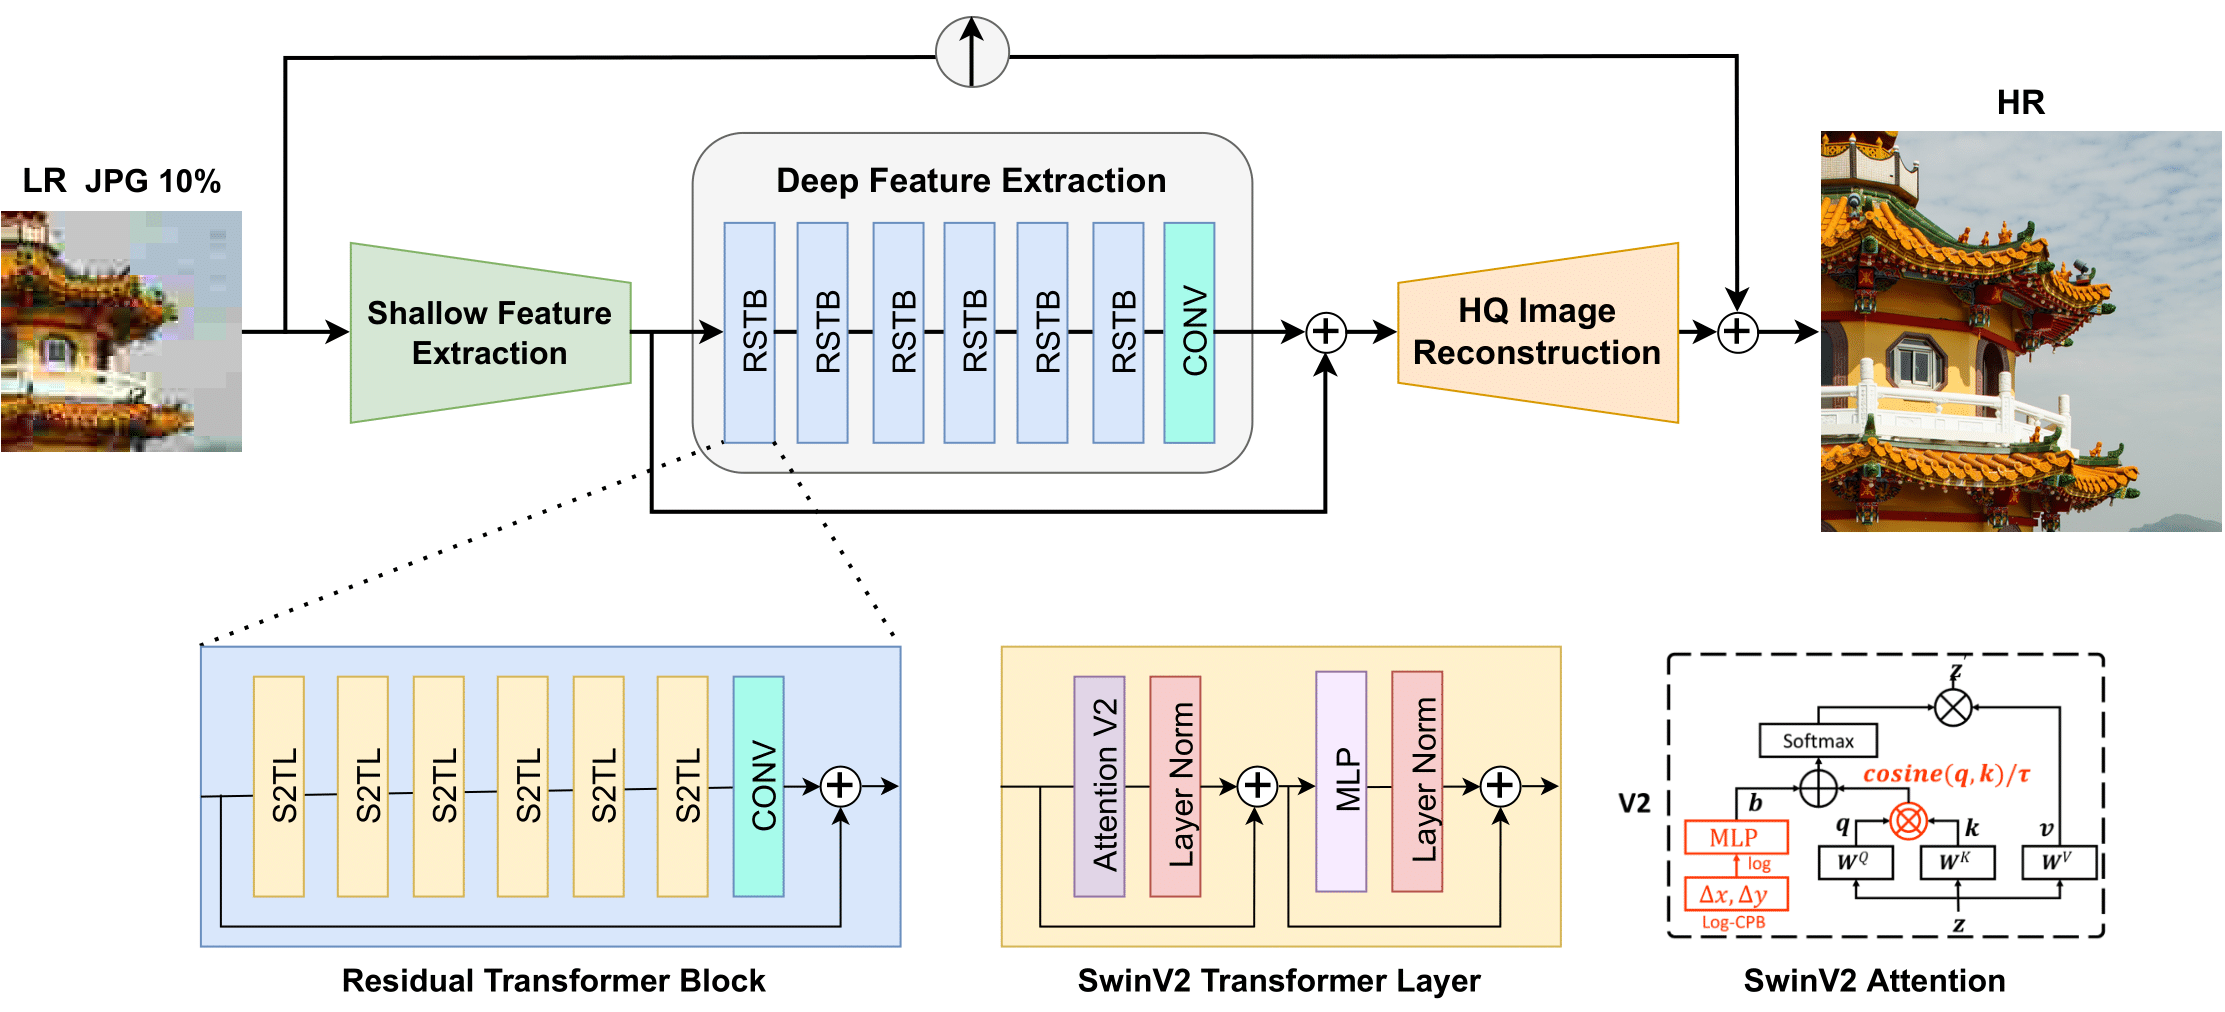

Swin2SR is a new version to the original SwinIR architecture, utilizing the new SwinV2 Transformer (more info [here](https://arxiv.org/abs/2111.09883)). This version has improved training performance for Super Resolution tasks, such as those in our project by up to 33% due to:  
- Post Normalization (instead of Pre Normalization)
- Scaled Cosine Attention (instead of dot product)
- Log-spaced continuous relative position bias

## Cost / Loss Function

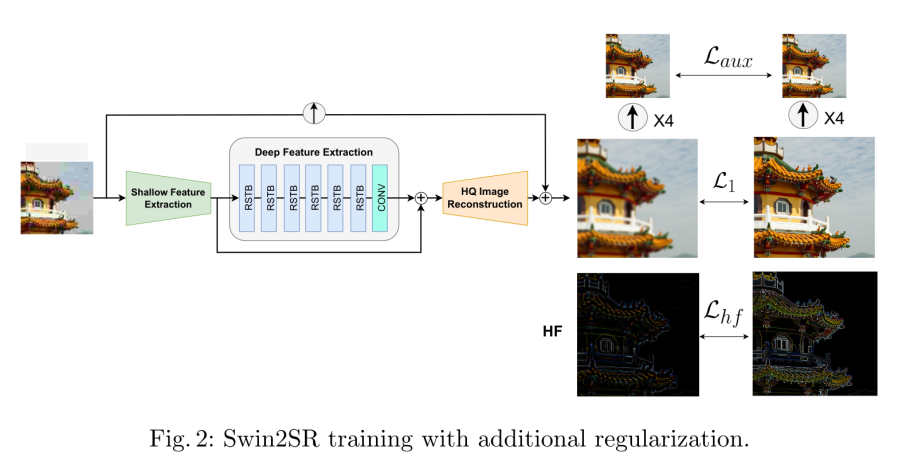

As you can see, Swin2SR uses 3 approaches to cost / loss functions:  
- **L1 loss** for reconstruction input vs. reference (baseline)
- **Laux** which minimizes L1 distance on *downsampled* input/reference (approach 2)
- **High-frequency (HF) feature extraction + Laux** (approach 3)

## Hyperparameters

As mentioned in the paper, the hyperparameters for this architecture are the RSTB number (# of blocks), S2TL number (# of Swins per block), window size, channel number, and attention head number.  

These hyperparameters are generally set as follows:  
- RSTB number = 6
- S2TL number = 6
- Window Size = 8
- Channel Number = 180
- Attention Head number = 6

## Import the model

First, install Transformers.

In [1]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Now, load Swin2SR model from Hugging Face. This model will upscale the image 2x.

In [2]:
from transformers import Swin2SRForImageSuperResolution

model = Swin2SRForImageSuperResolution.from_pretrained("caidas/swin2SR-classical-sr-x2-64")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/48.5M [00:00<?, ?B/s]

## Upload Images

Since we have our images loaded to Hugging Face, we can easily import and download a few to try.

Let's see a low resolution video game image.

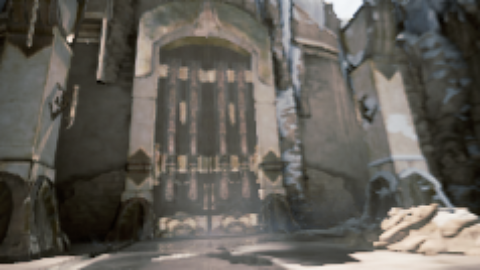

In [3]:
import requests
from PIL import Image

url = "https://huggingface.co/datasets/ericphann/video-game-super-resolution/resolve/main/training-lr/00000.png"

lr = Image.open(requests.get(url, stream=True).raw)
lr

Let's see the high resolution equivalent.

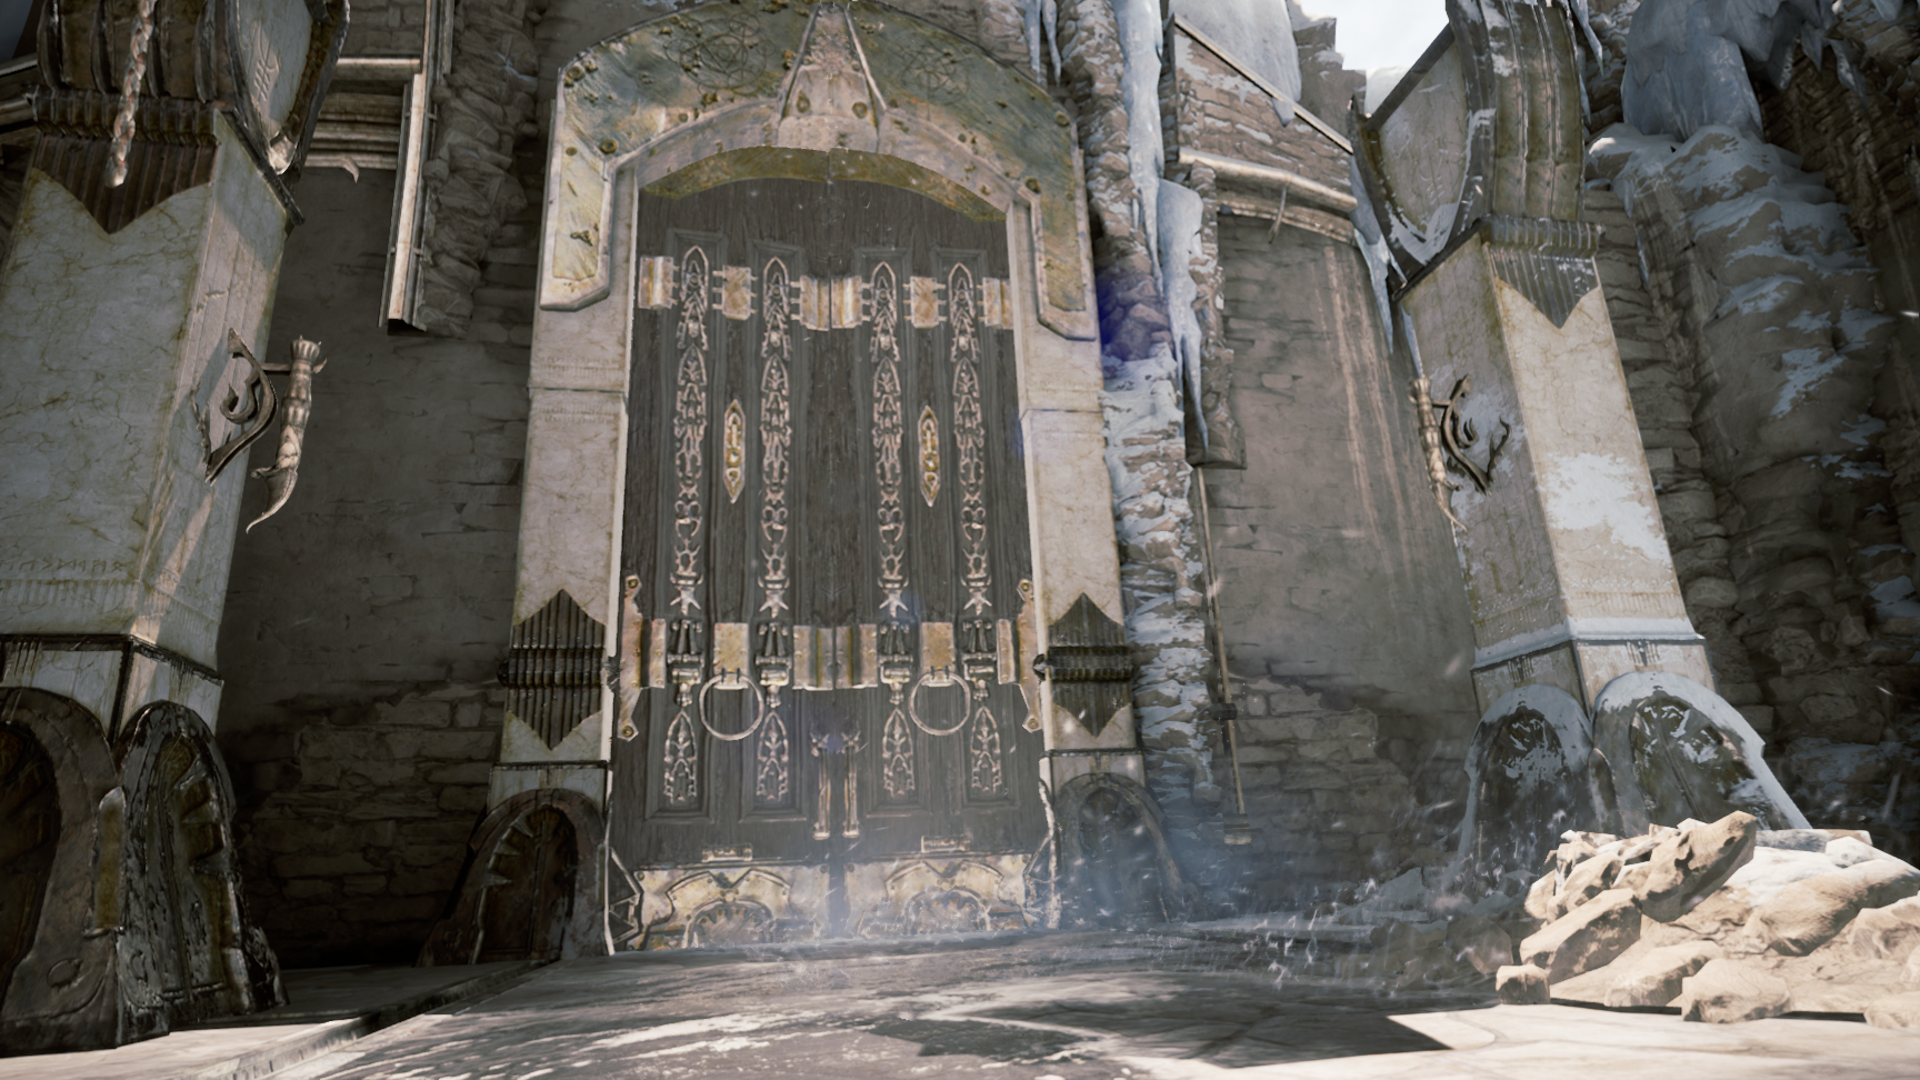

In [4]:
url = "https://huggingface.co/datasets/ericphann/video-game-super-resolution/resolve/main/training-hr/00000.png"

hr = Image.open(requests.get(url, stream=True).raw)
hr

## Prepare image

Swin2SR has a specific image processor, so let's run our low resolution image through that.

In [5]:
from transformers import Swin2SRImageProcessor

processor = Swin2SRImageProcessor()

In [6]:
pixel_values = processor(lr, return_tensors="pt", input_data_format="channels_last").pixel_values
print(pixel_values.shape)

torch.Size([1, 4, 272, 488])


We need to reshape the second column from RGBA (4 channel) to RGB (3 channel).

In [29]:
pixel_values = pixel_values[:,:3, :, :]
print(pixel_values.shape)

torch.Size([1, 3, 272, 488])


## Inference

In [8]:
import torch

with torch.no_grad():
  outputs = model(pixel_values)

## Visualize

The model outputs an upscaled version of our input image.

In [9]:
outputs.reconstruction.shape

torch.Size([1, 3, 544, 976])

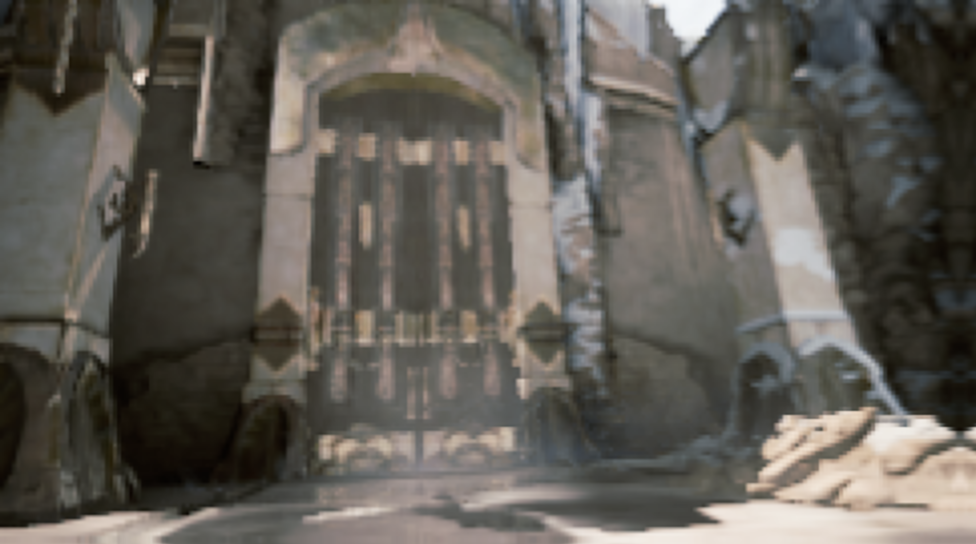

In [19]:
import numpy as np

output = outputs.reconstruction.data.squeeze().float().cpu().clamp_(0, 1).numpy()
output = np.moveaxis(output, source=0, destination=-1)
output = (output * 255.0).round().astype(np.uint8)  # float32 to uint8
hr_pred = Image.fromarray(output)
hr_pred

## Evaluate

Now let's evaluate the model prediction against our ground truth image. We will use two metrics:  
- **PSNR**: Peak signal-to-noise ratio, basic numerical measure of similarity. Simple and fast but doesn't reflect human perception well.
- **SSIM**: Structural similarity index, slightly slower than PSNR, but more reliable for perceptual quality as opposed to numerical accuracy.

First, let's import everything we will need.

In [21]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
from math import log10, sqrt

Now, let's create a `psnr` function.

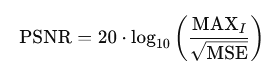

In [27]:
def calculate_psnr(img1, img2):
    img1 = np.array(img1).astype(np.float32)
    img2 = np.array(img2).astype(np.float32)
    mse = np.mean((img1 - img2) ** 2)

    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

Next, let's create a `ssim` function.

In [24]:
def calculate_ssim(img1, img2):
    img1 = np.array(img1)
    img2 = np.array(img2)
    return ssim(img1, img2, channel_axis=-1, data_range=255)

Since our ground truth hi-res is in a different resolution (and shape) than the prediction, let's resize it.

In [31]:
hr_resized = hr.convert('RGB')

In [34]:
hr_resized = hr_resized.resize(hr_pred.size, Image.BICUBIC)

Now, let's generate our metrics.

In [35]:
psnr_val = calculate_psnr(hr_resized, hr_pred)
ssim_val = calculate_ssim(hr_resized, hr_pred)

print(f"PSNR: {psnr_val:.2f} dB")
print(f"SSIM: {ssim_val:.4f}")

PSNR: 17.93 dB
SSIM: 0.3804


Interpreting these metrics:  
- The higher PSNR, the better. 17.93 is pretty poor and suggests a notable difference between the ground truth and prediction.
- The higher SSIM (range 0 to 1) the better. 0.3804 suggests low structural similarity, the overall output is still blurry.

Here's an example of PSNR in dB.  

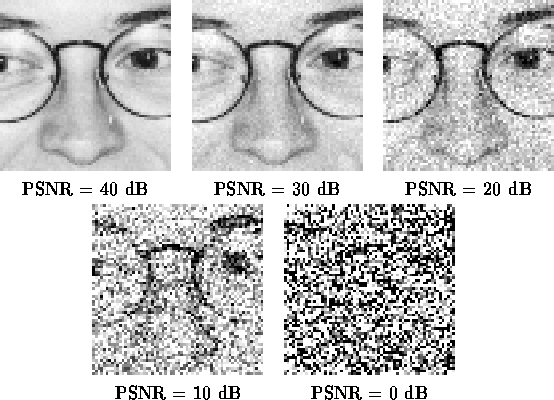

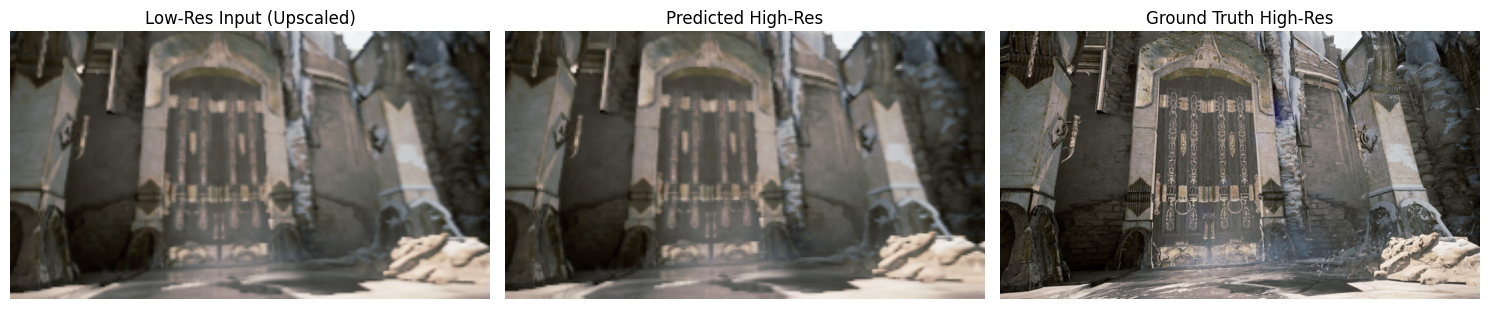

In [37]:
import matplotlib.pyplot as plt

# Resize low-res to match HR image size for comparison
lr = lr.convert('RGB')
lr_upscaled = lr.resize(hr_pred.size, Image.BICUBIC)

plt.figure(figsize=(15, 5))
titles = ["Low-Res Input (Upscaled)", "Predicted High-Res", "Ground Truth High-Res"]
images = [lr_upscaled, hr_pred, hr_resized]

for i, (title, img) in enumerate(zip(titles, images)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()


Just from initial impressions, it is not as good as we'd like. It is still pretty blurry despite a "higher resolution." For the next milestone, we will implement additional metrics and features to help produce better results.